# Coding Assignment 1
## Comparative Analysis of ML Classifiers for Medical Diagnosis

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — `sklearn.datasets.load_breast_cancer`  
**Models:** Logistic Regression · Random Forest · Support Vector Machine (SVM)  
**Phases:** A — Data Engineering | B — Model Implementation | C — Visualization

In [13]:
# Install required libraries (only needed on Google Colab)
!pip install -q numpy pandas matplotlib seaborn scikit-learn

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Phase A: Data Engineering (Pandas)

### Step 1 — Convert the raw Bunch object into a Pandas DataFrame with correct feature names

In [15]:
# Load the Breast Cancer Wisconsin (Diagnostic) dataset
cancer = load_breast_cancer()

# Convert raw Bunch object → Pandas DataFrame with correct feature names
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = Malignant, 1 = Benign

print("Dataset Shape:", df.shape)
print("\nTarget classes:", dict(enumerate(cancer.target_names)))
print("\nClass distribution:")
print(df['target'].value_counts())
df.head()

Dataset Shape: (569, 31)

Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 2 — Preprocessing: Check for missing values

In [16]:
# Check for missing values (dataset is clean, but the code must show the check)
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() == 0:
    print("\n[INFO] No missing values found. Dataset is clean and ready for processing.")
else:
    print("\n[WARNING] Missing values detected. Imputation required before training.")

Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing values: 0

[INFO] No missing values found. Dat

### Step 3 — Feature Scaling: Apply StandardScaler

In [17]:
X = df.drop('target', axis=1)
y = df['target']

# Apply StandardScaler to normalize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=cancer.feature_names)

print("Feature Scaling Applied: StandardScaler")
print(f"Mean after scaling (should be ~0): {X_scaled.mean().mean():.6f}")
print(f"Std  after scaling (should be ~1): {X_scaled.std().mean():.6f}")

Feature Scaling Applied: StandardScaler
Mean after scaling (should be ~0): -0.000000
Std  after scaling (should be ~1): 1.000880


### Step 4 — Correlation Matrix: Top 5 features most correlated with target

Top 5 features most correlated with target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636


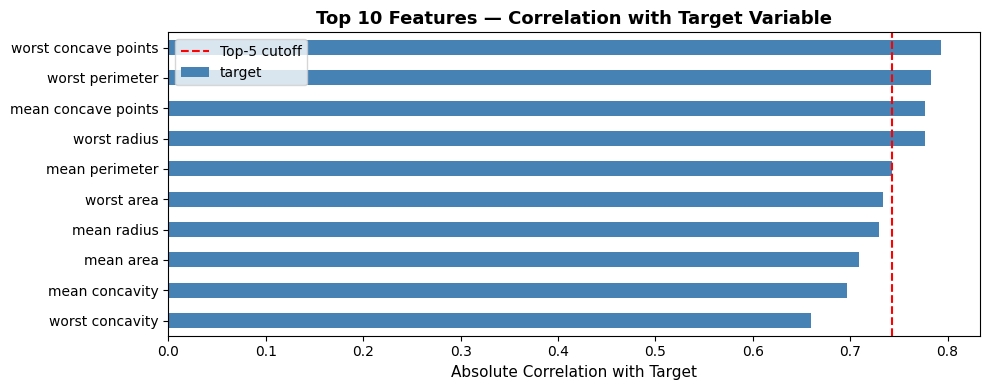

In [18]:
# Use Pandas to find the top 5 features most correlated with the target variable
df_scaled = X_scaled.copy()
df_scaled['target'] = y.values

correlation = df_scaled.corr()['target'].drop('target').abs().sort_values(ascending=False)

print("Top 5 features most correlated with target:")
print(correlation.head(5).to_string())

# Visualise the top 10 correlations
fig, ax = plt.subplots(figsize=(10, 4))
correlation.head(10).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Absolute Correlation with Target", fontsize=11)
ax.set_title("Top 10 Features — Correlation with Target Variable", fontsize=13, fontweight='bold')
ax.axvline(x=correlation.iloc[4], color='red', linestyle='--', label='Top-5 cutoff')
ax.legend()
plt.tight_layout()
plt.savefig('assignment1_feature_correlation.png', dpi=150)
plt.show()

---
## Phase B: Model Implementation (Scikit-Learn)

Three classification algorithms:
1. **Logistic Regression** — Baseline
2. **Random Forest Classifier** — Ensemble method
3. **Support Vector Machine (SVM)** — RBF kernel

In [19]:
# Train-Test Split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 455
Testing  samples : 114


In [20]:
# 1. Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("[1] Logistic Regression trained.")

# 2. Random Forest Classifier (Ensemble method)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("[2] Random Forest Classifier trained.")

# 3. Support Vector Machine (SVM) with RBF kernel
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print("[3] Support Vector Machine (SVM) trained.")

[1] Logistic Regression trained.
[2] Random Forest Classifier trained.
[3] Support Vector Machine (SVM) trained.


In [21]:
# Compute Accuracy, Precision, Recall for all models
models = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest':       (rf_model, rf_pred),
    'SVM (RBF)':           (svm_model, svm_pred),
}

results = {}
for name, (model, pred) in models.items():
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
    }

results_df = pd.DataFrame(results).T
print("\n=== Model Performance Summary ===")
print(results_df)


=== Model Performance Summary ===
                     Accuracy  Precision  Recall
Logistic Regression    0.9825     0.9861  0.9861
Random Forest          0.9561     0.9589  0.9722
SVM (RBF)              0.9825     0.9861  0.9861


---
## Phase C: Visualization (Matplotlib)

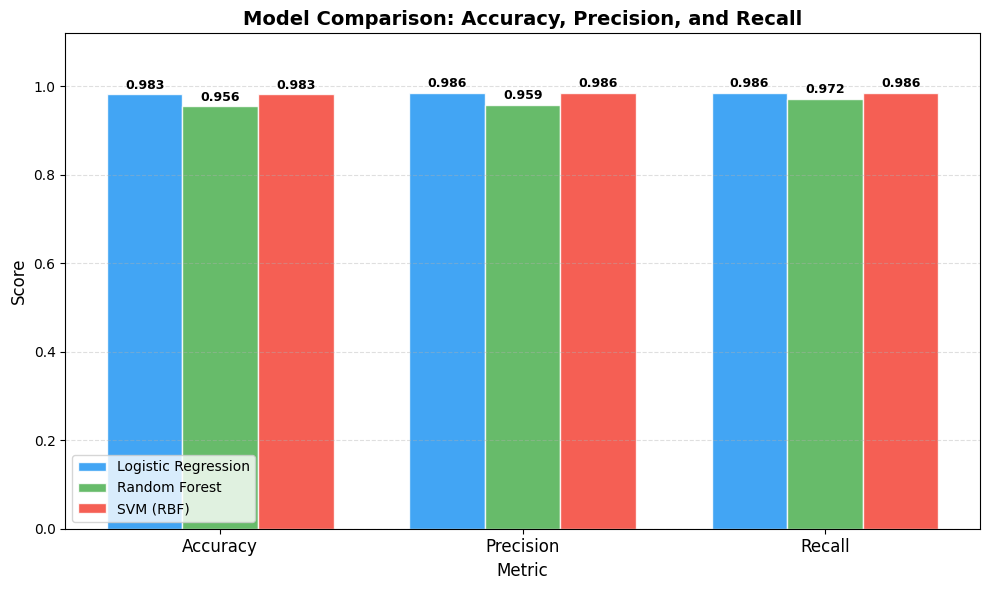

In [22]:
# Plot 1: Model Comparison Bar Chart — Accuracy, Precision, Recall
metrics = ['Accuracy', 'Precision', 'Recall']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2.0,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy, Precision, and Recall', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('assignment1_model_comparison.png', dpi=150)
plt.show()

Best Model: Logistic Regression  (Accuracy = 0.9825)


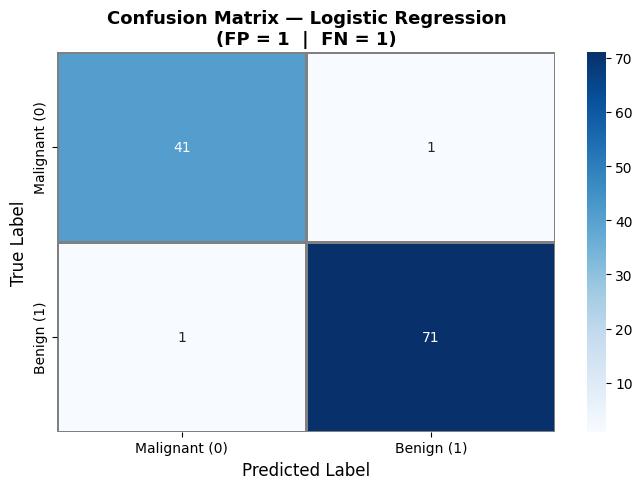

True  Positives : 71
True  Negatives : 41
False Positives : 1  (Benign predicted as Malignant)
False Negatives : 1  (Cancer missed!)


In [23]:
# Plot 2: Confusion Matrix Heatmap — best-performing model
best_model_name = results_df['Accuracy'].idxmax()
best_pred       = models[best_model_name][1]
print(f"Best Model: {best_model_name}  (Accuracy = {results_df.loc[best_model_name, 'Accuracy']})")

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Malignant (0)', 'Benign (1)'],
    yticklabels=['Malignant (0)', 'Benign (1)'],
    linewidths=1, linecolor='gray'
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(FP = {fp}  |  FN = {fn})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assignment1_confusion_matrix.png', dpi=150)
plt.show()

print(f"True  Positives : {tp}")
print(f"True  Negatives : {tn}")
print(f"False Positives : {fp}  (Benign predicted as Malignant)")
print(f"False Negatives : {fn}  (Cancer missed!)")

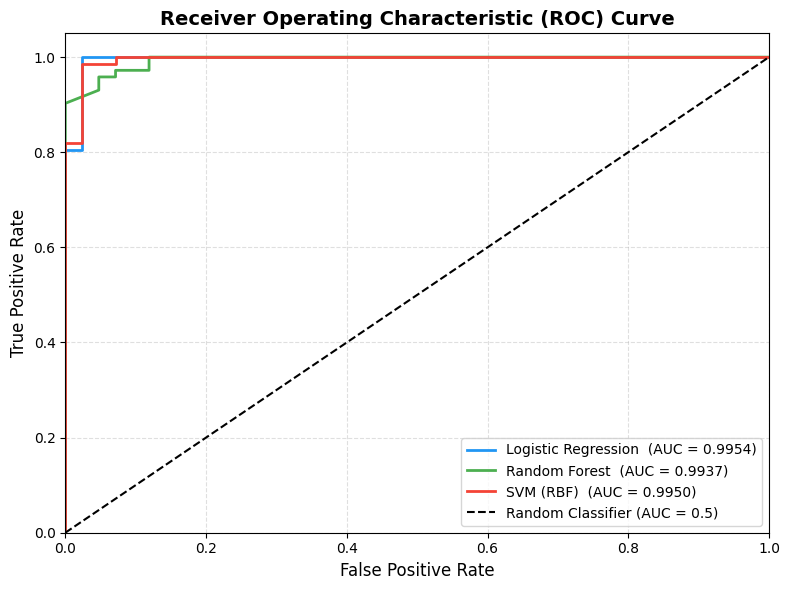

In [24]:
# Plot 3: ROC Curve — all three models
fig, ax = plt.subplots(figsize=(8, 6))

for (name, (model, _)), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.0, label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('assignment1_roc_curve.png', dpi=150)
plt.show()